### Good reading blog, machinelearning.apple.com/research/

# Pytorch Computer Vision

* See reference Notebook -
* See reference online book -

## 0. Computer vision libraries in PyTorch

* `torchvision` - [base domain library for torchvision]
* `torchvision.datasets` - get datasets and data loading functions for computer vision
* `torchvision.models` - get pretained computerviison models that you can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vison data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch.
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset

### Reminder: ***Read the PyTorch documentation of Computer Vision***

***LINK: pytorch.org/vision/stable/transforms.html***

In [1]:
# import PyTorch

import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.13.0+cu126
0.28.0+cu126


## 1. Getting a Dataset

The data we'll be using is Fashion MNIST
ol 

In [2]:
from torchvision import datasets

train_data = datasets.FashionMNIST(
    root = "datasets", # where to download the data?
    train= True, # do we want the training dataset?
    download = True, # Do we want to download?
    transform = torchvision.transforms.ToTensor(), # How do we want to transofmr the data
    target_transform = None # How do we want to transform the lables/targets
    )

test_data = datasets.FashionMNIST(
    root = "datasets",
    train=False,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# train_data[0]

In [5]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
# Gives a list of classes

train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
# Gives the labels as well as the indices

class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
image.shape

torch.Size([1, 28, 28])

In [10]:
# Check the shape of our image

print(f"Image Shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image Shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


Image shape: torch.Size([1, 28, 28])


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

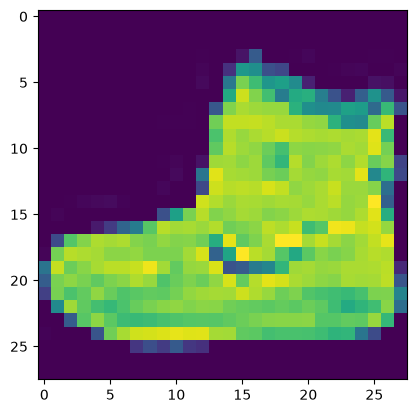

In [11]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
image

Text(0.5, 1.0, 'Ankle boot')

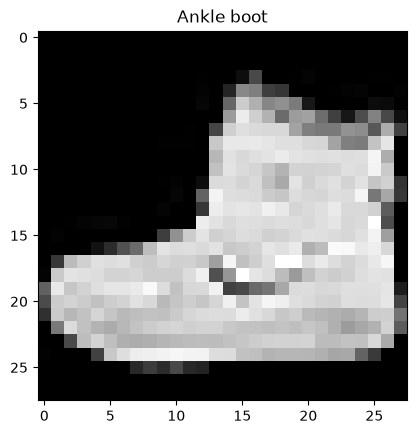

In [12]:
plt.imshow(image.squeeze(), cmap = "gray");
plt.title(class_names[label])

In [13]:
# random_idx = torch.randint(0, len(train_data), size = [1]).item()
# random_idx

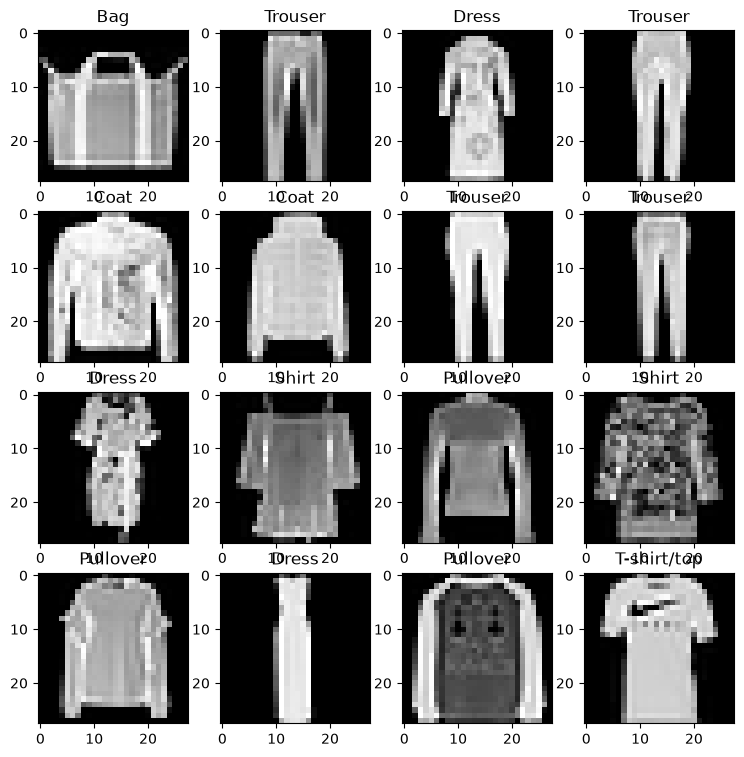

In [14]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize = (9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])

Do you think these items of clothing (images) could be modelled with pure linear lines or do you think we'll need non-linearities?

In [15]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: datasets
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: datasets
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now our data is in the form of PyTorch Datasets.

DataLoader turns out dataset into a Python iterable

More specificallly, we want to turn our data into batches (ior mini-batches)

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may noty be able to loook (store in memeory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32)
2. It gives our neural network more chances to update it's gradients per epoch

In [ ]:
# Mini batches follows you everywhere regardless of data (photo, video, audio, etc)

from torch.utils.data import DataLoader

# setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x197504a3e00>,
 <torch.utils.data.dataloader.DataLoader at 0x19751647750>)

In [17]:
# Let's check out what we've created


print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of the train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Lenght of the test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000197504A3E00>, <torch.utils.data.dataloader.DataLoader object at 0x0000019751647750>)
Length of the train dataloader: 1875 batches of 32...
Lenght of the test dataloader: 313 batches of 32...


In [18]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.5922, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [19]:
# Show a sample 
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()

## 3. Model:0 Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best epractice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models/experiemnts.

In other words: start simply and add complexity when necessary

In [20]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a simple sample
X = train_features_batch[0]

# Flatten the sample
output = flatten_model(X) # perform forward pass

# Print out what happeend
print(f"Shape before flattening {X.shape}")
print(f"Shape after flatting {output.shape}")

Shape before flattening torch.Size([1, 28, 28])
Shape after flatting torch.Size([1, 784])


In [21]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_layer: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_layer),
            nn.Linear(in_features=hidden_layer,
                      out_features = output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

In [22]:
len(class_names)

10

In [23]:
torch.manual_seed(42)

epochs = 200
input_shape = label
hidden_layer = 32
output_shape = label


# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape = 784, # This is 28 * 28
    hidden_layer= 10,
    output_shape= len(class_names),
).to('cpu')



In [24]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [25]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation matrix

* Loss function - since we are working with multi-class data, our loss function will be `nn.CrossEntrophyLoss()`
* Optimizerr- our optimizer `torch.optim.SGD()` (stocastic gradient descent)
* Evaluation metric - since we are working on a classification problem, we will use accuracy as an evaluation matrix.

In [26]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_funfctions.py", "wb") as f:
        f.write(request.content)


helper_functions.py already exists, skipping download


In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss function and optimizerr
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = loaded_model.parameters(),
                            lr = 0.1)

In [28]:
# accuracy_fn()

### 3.2 Creating a function to time our experiments

Machine learning is very experimental

Two of the main things you often want to track would be:
1. Model's performance (loss and accuracy values etc)
2. How fast it runs

In [29]:
from timeit import default_timer as timer
def print_train_time(start:float,
                    end:float,
                    device: torch.device = None):
    """ Prints difference between start and end time."""

    total_time = end - start
    print(f"Train time on {device}: {total_time: 3f} seconds")
    return total_time

In [30]:
start_time = timer()
# some code..
end_time = timer()
print_train_time(start = start_time, end = end_time)

Train time on None:  0.000036 seconds


3.5900011425837874e-05

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*
4. Print out what's happening
5. Time it all (for fun).

In [31]:
# # Import tqdm for progress bar
# from tqdm.auto import tqdm

# # Set the seed and start the timer
# torch.manual_seed(42)
# train_time_start_oncpu = timer()

# # Set the number of epochs (we'll keep it small for faster training time)
# epochs = 3

# # Create training and test loop
# for epoch in tqdm(range(epochs)):
#     print(f"Epoch: {epoch}\n-------")

#     ## Training
#     train_loss = 0

#     # Add a loop to loop through the training batches
#     for batch, (X, y) in enumerate(train_dataloader):
#         model_0.train()

#         #1. Forward pass
#         y_pred = model_0(X)

#         #2. Calculate loss (per batch)
#         loss = loss_fn(y_pred, y)
#         train_loss += loss # accumulate the train loss

#         # 3. Optimizer zero grad
#         optimizer.zero_grad()

#         #4. Backward loss
#         loss.backward()

#         #5 Optimizer step
#         optimizer.step()

#         if batch % 200 == 0:
#             print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")
            

#         # Divide total train loss by length of train dataloader
#         train_loss /= len(train_dataloader)

#         ## Testing
#         test_loss, test_acc = 0,0
        
#         model_0.eval()

#         with torch.inference_mode():
#             for X_test, y_test in test_dataloader:
#                 #1. Forward pass
#                 test_pred = model_0(X_test)

#                 # 2. Calculate the loss (accumaulatively)
#                 test_loss += loss_fn(test_pred, y_test)

#                 # 3. Calculate accuracy
#                 test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim = 1))

#             # Calcullate the test loss average per batch
#             test_loss /= len(test_data)




In [32]:
# ## Save the model
# from pathlib import Path
# MODEL_PATH = Path("models")
# MODEL_PATH.mkdir(parents = True, exist_ok = True)

# MODEL_NAME = "Fashion_model_0_trained_(without eval).pth"
# MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# torch.save(obj = model_0.state_dict(), f=MODEL_SAVE_PATH)
# print(f"Model saved to {MODEL_SAVE_PATH}")

### 4. Make predictions and get Model 0 results

In [33]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """ Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0

    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            # Make predictions
            y_pred = model(X)

            # ACcumulate the loss and acc values per batch
            loss += loss_fn(y_pred, y)
            acc+= accuracy_fn(y_true = y,
                              y_pred = y_pred.argmax(dim = 1))

            # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
                "model_loss": loss.item(),
                "model_acc": acc}

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 5 . Setup device agnostic-code (if there is a GPU available)

In [71]:
from pathlib import Path

# Caclulate model 0 results on test datasets
MODEL_PATH = Path("models")
MODEL_NAME = "Fashion_model_0_trained_(without eval).pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

loaded_model_0 = FashionMNISTModelV0(input_shape = 784, hidden_layer = 10, output_shape = len(class_names))
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [72]:
loaded_model_0.to(device)

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [74]:
loaded_model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [75]:
loaded_model_0_results = eval_model(model = loaded_model_0,
                             data_loader = test_dataloader,
                             loss_fn= loss_fn,
                             accuracy_fn = accuracy_fn)

loaded_model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4694799780845642,
 'model_acc': 83.2667731629393}

### 5. Setup device agnostic Code (for using GPU if there is one)

In [41]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_layer: int,
                 output_shape: int):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, 
                      out_features = hidden_layer),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layer, 
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [42]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_layer = 128,
                              output_shape=len(class_names)).to(device)

In [43]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [44]:
!nvidia-smi

Wed Aug 12 13:55:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   54C    P3             17W /   35W |     894MiB /   4096MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 5.1 Setup loss, optimizer and evaluation metrics

In [45]:
from helper_functions import accuracy_fn

loss_fn_model_1 = nn.CrossEntropyLoss()
opt_model_1 = torch.optim.SGD(params = model_1.parameters(),
                              lr = 0.1)

### 6.2 Functionzing training and evaluation/testing loops
Let's create a function for:
* training loop called `train_step()`
* testing loop called `test_step()`

In [46]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    """ Performs a training with model trying to learn on data_loader"""

    train_loss, train_acc = 0, 0

    # Add a loop to loop through the training batches
    for batch, (X_train, y_train) in enumerate(data_loader):


        # Put data on target device
        X_train, y_train = X_train.to(device), y_train.to(device)

        model.train()

        #1. Forward pass
        y_pred = model(X_train)

        #2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y_train)
        train_loss += loss # accumulate the train loss
        train_acc += accuracy_fn(y_true = y_train,
                                 y_pred = y_pred.argmax(dim = 1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

         #4. Backward loss
        loss.backward()

        #5 Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss: .5f} | Train acc: {train_acc: .2f}%")


c:\Users\hassa\Documents\Practice\Pytorch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
len(train_dataloader)

1875

In [48]:
def test_step(model: torch.nn.Module,
             data_loader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module,
             accuracy_fn,
             device: torch.device = device):    
        """ Performs a testing loop step on model going over data_loader"""

        test_loss, test_acc = 0,0
        
        model.eval()

        with torch.inference_mode():
            for X_test, y_test in data_loader:
                X_test, y_test = X_test.to(device), y_test.to(device)

                #1. Forward pass
                test_pred = model(X_test)

                # 2. Calculate the loss (accumaulatively)
                test_loss = loss_fn(test_pred, y_test)
                test_loss += test_loss

                # 3. Calculate accuracy
                accuracy = accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim = 1)) # GOing to from logits to predictions label
                test_acc += accuracy

            # Calcullate the test loss average per batch
            test_loss /= len(data_loader)
            test_acc /= len(data_loader)
            print(f"Test loss: {test_loss: .5f} | Test acc: {test_acc: .2f}%")

In [49]:
len(class_names)

10

In [50]:
# initilizing everything for a new model to test our function

model_2 =  FashionMNISTModelV1(input_shape=784,
                               hidden_layer = 30,
                               output_shape=len(class_names)).to(device)

# Loss
loss_fn_2 = torch.nn.CrossEntropyLoss()
opt_fn_2 = torch.optim.SGD(params = model_2.parameters(),
                              lr = 0.05)

In [51]:
torch.manual_seed(42)
epochs = 10

for epoch in tqdm(range(epochs)):
    print(f"Epoch number: {epoch}")
    train_step(model = model_2,
               data_loader = train_dataloader,
               loss_fn = loss_fn_2,
               optimizer= opt_fn_2,
               accuracy_fn = accuracy_fn,
               device = device)

    test_step(model = model_2,
              data_loader = test_dataloader,
              loss_fn = loss_fn_2,
              accuracy_fn = accuracy_fn,
              device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch number: 0
Train loss:  0.62737 | Train acc:  78.09%


 10%|█         | 1/10 [00:14<02:13, 14.83s/it]

Test loss:  0.00162 | Test acc:  82.56%
Epoch number: 1
Train loss:  0.44739 | Train acc:  84.01%


 20%|██        | 2/10 [00:29<01:58, 14.76s/it]

...

Test loss:  0.00109 | Test acc:  86.32%
Epoch number: 8
Train loss:  0.32998 | Train acc:  88.12%


 90%|█████████ | 9/10 [02:12<00:14, 14.71s/it]

Test loss:  0.00147 | Test acc:  86.77%
Epoch number: 9
Train loss:  0.32264 | Train acc:  88.41%


100%|██████████| 10/10 [02:27<00:00, 14.73s/it]

Test loss:  0.00098 | Test acc:  86.76%


**Note:** Sometimes, depending on your data?hardware you might gind that your odel trains faster on CPu than GPU.

Why is this?

1. It could be that the overhead ofor copying data/mopdel to and from the GPU outweighs the compute benefits offered by the GPU.
2. The hardware you are using has a better cPU in terms of compute capabilitiy than your GPU.

Article to read to make your models compute faster: https://horace.io/brrr_intro.html

In [52]:
# Get model_1 results dictionary

model_2_results = eval_model(model = model_2,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)

In [53]:
model_2_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.37528854608535767,
 'model_acc': 86.7611821086262}

## Model 2: building a Convolutional Neural Network (CNN)

CNN's are also known ConvNets

CNN's are known for their capabilities for finding patterns

Website: https://poloclub.github.io/cnn-explainer/

Maxpool2D: https://docs.pytorch.org/docs/2.13/generated/torch.nn.MaxPool2d.html

In [54]:
# Create a convolutional Neural network
class FashionMNISTModelV3(nn.Module):
    """
    Model architecture that replicates the TinyVGG model
    from CNN explainer webssite
    """

    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.cnn_block_1 = nn.Sequential(
            # Create a conv layer
            nn.Conv2d(in_channels = input_shape,
                      out_channels=hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1), # values we can set ourselves in our NN's are called hyperparameter,
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.cnn_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, # There is a trick to calculating this
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn_block_1(x)
        print(x.shape)
        x = self.cnn_block_2(x)
        print(x.shape)
        x = self.classifier(x)
        return x

In [55]:
torch.manual_seed(42)
# Input shape/input_channels depends on if the image is black and white (1) or color (3)
model_3 = FashionMNISTModelV3(input_shape = 1,
                              hidden_units=10,
                              output_shape = len(class_names)).to(device)

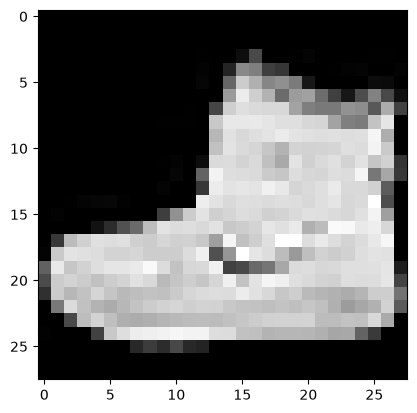

In [56]:
plt.imshow(image.squeeze(), cmap = "gray")

In [57]:
model_3(image.unsqueeze(0).to(device))

torch.Size([1, 10, 14, 14])
torch.Size([1, 10, 7, 7])


tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [58]:
rand_image_tensor = torch.randn(size = (1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [59]:
print(image.shape)

torch.Size([1, 28, 28])


In [60]:
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [61]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels = 1,
                       out_channels = 10,
                       kernel_size = 3,
                       stride = 1,
                       padding = 0)

In [62]:
conv_output = conv_layer(rand_image_tensor)

In [63]:
conv_output

tensor([[[ 0.4910, -0.8239, -0.2863,  ...,  0.5243,  0.8126,  0.0728],
         [-0.5280, -0.9493,  0.6458,  ..., -0.9807, -1.0891,  0.7675],
         [-0.7414,  0.7719, -0.3809,  ...,  0.1199,  0.5462,  0.6062],
         ...,
         [ 0.4469, -0.0532,  0.3301,  ..., -0.7198,  0.2540,  0.8046],
         [-0.4678,  0.7292,  0.0327,  ..., -0.2579,  0.6155, -0.2300],
         [ 0.0436,  0.4125, -0.0740,  ..., -1.0246, -0.2585,  0.4938]],

        [[ 0.2173, -1.2055, -0.5142,  ..., -0.0697, -0.0977, -0.2681],
         [ 0.1357,  0.1282, -0.4279,  ..., -0.3519, -0.5099,  0.6130],
         [-0.7819, -0.3941, -0.6670,  ..., -0.4448, -0.1641, -0.0936],
         ...,
         [ 1.5588,  0.6268, -0.1758,  ..., -0.8730,  0.4867,  0.3033],
         [-0.8081,  0.5847, -0.7841,  ...,  0.0177, -0.0325, -0.5194],
         [ 0.7569, -0.5978, -0.7900,  ..., -0.4572,  0.3552,  0.2675]],

        [[ 0.6309, -0.0718,  0.0153,  ..., -0.1602,  0.1779, -0.4545],
         [ 0.3503,  0.1566,  0.9585,  ...,  0

### 8. Compare model results and training time

In [81]:
import pandas as pd

compare_results = pd.DataFrame(
    [loaded_model_0_results, 
     model_2_results])

In [82]:
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.469480,83.266773
1,FashionMNISTModelV1,0.375289,86.761182


In [83]:
# Add training time to rtesults comparison (perforamnce vs speed trade off)
compare_results.columns

Index(['model_name', 'model_loss', 'model_acc'], dtype='str')

Text(0.5, 0, 'accuracy (%)')

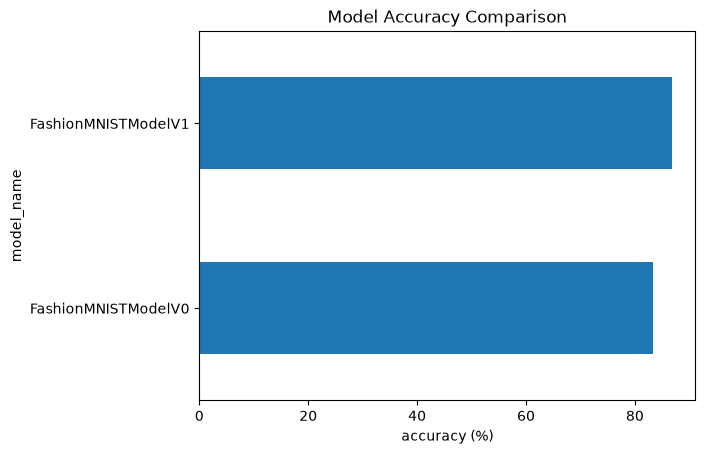

In [87]:
# Visualize our model results

compare_results.set_index("model_name")["model_acc"].plot(kind = "barh", title = "Model Accuracy Comparison")
plt.xlabel("accuracy (%)")

### 9. Make and evaluate random predictions with best model

In [89]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
    """ Returns predictions for a list of images."""
    model.to(device)

    model.eval()

    pred_probs_list = []

    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim = 0).to(device)

            # Forward pass (model outputs raw logits)
            pred_logit = model(sample)

            # GEt predictions probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim = 1)

            # Get pred_prob off the GPU for further calculations (why on CPU?)
            pred_probs_list.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs_list)

In [93]:
test_data[0][:10]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

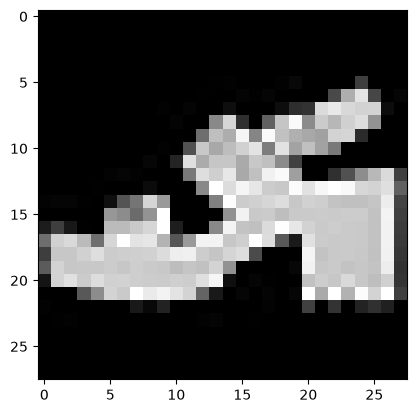

In [96]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")